In [20]:
import pandas as pd
import numpy as np
import random
import copy
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [21]:
def print_pop(population):
    for ind in population:
        print(ind)

In [22]:
def initialize_map(p_zero, N):

  the_map = np.zeros((N,N));

  for i in range(0, N):
    for j in range (0, i):
      if random.random() > p_zero:
          the_map[i][j] = random.random()
          the_map[j][i] = the_map[i][j]

          return the_map

In [23]:
def initialize_complex_map(p_zero, N, groups ):

  the_map = np.zeros((N,N));

  for i in range(0, N):
    for j in range(0, i):
        group_i = int(i/(N/groups))
        group_j = int(j/(N/groups))

        if random.random() > p_zero and abs(group_i = group_j) <= i:
            the_map[i][j] = random.random()
            the_map[j][i] = the_map[i][j]

    ax = sns.heatmap(the_map)
    plt.show()

    return the_map

In [24]:
def create_starting_population(size, the_map):

    population = []

    for i in range(0, size):
        population.append(create_new_member(the_map))

    return population

In [25]:
def fitness(route, the_map):
    score = 0
    for i in range(1, len(route)):
        if the_map[route[i-1]][route[i]] == 0:
            print("WARNING: INVALID ROUTE")
            print("Route:", route)
            print("Map:", the_map)
        else:
            score += the_map[route[i-1]][route[i]]
    return score

In [26]:
import random

def crossover(a, b):
    common_elements = list(set(a) & set(b))

    if not common_elements:
        # If no common elements, return the parents as they are
        return a, b

    if 0 in common_elements:
        # Avoid removing '0' if it is a common element
        common_elements.remove(0)

    if not common_elements:
        # If '0' was the only common element, return the parents as they are
        return a, b

    # Remove the maximum element from one of the parents
    common_elements.remove(max(a))

    # Select a value randomly from the remaining common elements
    value = random.sample(common_elements, 1)[0]

    # Perform crossover
    index_a = a.index(value)
    index_b = b.index(value)

    new_1 = a[:index_a] + b[index_b:]
    new_2 = b[:index_b] + a[index_a:]

    return new_1, new_2

# Rest of your code...


In [27]:
def mutate(route, probability, the_map):
    new_route = copy.deepcopy(route)

    for i in range(1, len(new_route)):
        if random.random() < probability:
            go = True
            while go:
                possible_values = np.nonzero(the_map[new_route[i - 1]])
                proposed_value = random.randint(0, len(possible_values[0]) - 1)
                new_route = np.append(new_route, possible_values[0][proposed_value])

                if new_route[i] == len(the_map) - 1:
                    go = False
                else:
                    i += 1

    return new_route

In [28]:
def create_new_member(the_map):
    N = len(the_map)
    route = np.zeros(1, dtype=int)
    go = True
    i = 0

    while go:
        possible_values = np.nonzero(the_map[route[i]])

        if not possible_values[0]:
            go = False
        else:
            proposed_value = random.choice(possible_values[0])
            route = np.append(route, proposed_value)

            if route[i] == N - 1:
                go = False
            else:
                i += 1

    return route

In [29]:
def score_population(population, the_map):
    scores = []

    for i in range(0, len(population)):
        scores.append(fitness(population[i], the_map))

    return scores


In [30]:
def pick_mate(scores):
    array = np.array(scores)
    temp = array.argsort()
    ranks = np.empty_like(temp)
    ranks[temp] = np.arange(1, len(array) + 1)

    fitness_values = [len(ranks) - x for x in ranks]

    cum_scores = copy.deepcopy(fitness_values)
    for i in range(1, len(cum_scores)):
        cum_scores[i] = fitness_values[i] + cum_scores[i - 1]

    probs = [x / cum_scores[-1] for x in cum_scores]
    rand = random.random()

    for i in range(0, len(probs)):
        if rand < probs[i]:
            return i

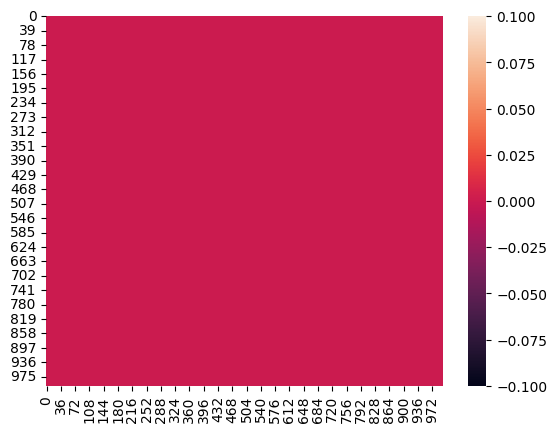

<ipython-input-28-ff17049f6d7b>:10: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if not possible_values[0]:


In [31]:
def main():
    # Parameters
    sparseness_of_map = 0.95
    size_of_map = 1000
    population_size = 30
    number_of_iterations = 1000
    number_of_couples = 9
    number_of_winners_to_keep = 2
    mutation_probability = 0.05
    number_of_groups = 1

    # Initialize the map and save it
    the_map = initialize_complex_map(sparseness_of_map, size_of_map, number_of_groups)

    # Create the starting population
    population = create_starting_population(population_size, the_map)

    last_distance = 1000000000

    for i in range(number_of_iterations):
        new_population = []

        # Evaluate the fitness of the current population
        scores = score_population(population, the_map)
        best_index = np.argmax(scores)
        best = population[best_index]
        number_of_moves = len(best)

        # Check if 'distance' is defined before using it
        if 'distance' in locals():
            if distance != last_distance:
                print(f'Iteration {i}: Best so far is {number_of_moves} steps for a distance of {distance}')
                plot_best(the_map, best, i)

        distance = fitness(best, the_map)

        # Allow members of the population to breed based on their relative score
        for j in range(number_of_couples):
            mate1 = population[pick_mate(scores)]
            mate2 = population[pick_mate(scores)]
            new_1, new_2 = crossover(mate1, mate2)
            new_population += [new_1, new_2]

        # Mutate
        for j in range(len(new_population)):
            new_population[j] = np.copy(mutate(new_population[j], mutation_probability, the_map))

        # Keep members of the previous generation
        new_population += [population[best_index]]

        for j in range(1, number_of_winners_to_keep):
            keeper = pick_mate(scores)
            new_population += [population[keeper]]

        # Add new random members
        while len(new_population) < population_size:
            new_population += [create_new_member(the_map)]

        # Replace the old population with a real copy
        population = copy.deepcopy(new_population)
        last_distance = distance

    # Plot the results after the loop
    plt.show()

if __name__ == "__main__":
    main()

In [32]:
def plot_best(the_map, route, iteration_number):
    ax = sns.heatmap(the_map)

    x = [0.5] + [x + 0.5 for x in route[:-1]] + [len(the_map) - 0.5]
    y = [0.5] + [x + 0.5 for x in route[1:]] + [len(the_map) - 0.5]

    plt.plot(x, y, marker='o', linewidth=4, markersize=12, linestyle='-', color='white')

    plt.savefig(f"images/new1000plot_{iteration_number}.png", dpi=300)
    plt.show()